In [84]:
import pandas as pd # Data Manipulation
import numpy as np # mathematical operation
import seaborn as sns # visualization
import matplotlib.pyplot as plt #  for visualization

In [85]:
#used to load the data set
df=pd.read_csv('/content/matches.csv')

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   season           756 non-null    int64 
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

In [87]:
#to checking the missing value
#EDA(exploratory data analysis)
#any machine learning algorithm only access in numerical way we have to use the tralator
#11 data types ,1 numerical data type
#machine learning algorithm can not handle the noise data
df.isnull().sum()#tells how many missing values in the data set(column)
print(df.isnull().sum())#null function is used to check the missing values



id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64


In [88]:
df.duplicated().sum()#finds the duplicated value
print(df.duplicated().sum())
#drop is the function to delete the duplicate the function if any duplicates are there
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())


0
0


In [89]:
#Basic Cleanup:filling Missing values
#1.Mode
 #(If the column has a missing value and  it is object(object means anything that not be expressed in numerical value) data type we replace that object with the mode")
#if the data is numerical data type
 #find out outliers(high and low num)in the numerical data type columns
 #to replace the missing values in numerical columns,we need to check the outliners
#2.Mean
#3.Median


In [90]:
#missing value treatment for object(mode)
df['city']=df['city'].fillna(df['city'].mode()[0])
df['winner']=df['winner'].fillna(df['winner'].mode()[0])
df['player_of_match']=df['player_of_match'].fillna(df['player_of_match'].mode()[0])
df['umpire1']=df['umpire1'].fillna(df['umpire1'].mode()[0])
df['umpire2']=df['umpire2'].fillna(df['umpire2'].mode()[0])
df['umpire3']=df['umpire3'].fillna(df['umpire3'].mode()[0])

In [91]:
df.isnull().sum()
print(df.isnull().sum())

id                 0
season             0
city               0
date               0
team1              0
team2              0
toss_winner        0
toss_decision      0
result             0
dl_applied         0
winner             0
win_by_runs        0
win_by_wickets     0
player_of_match    0
venue              0
umpire1            0
umpire2            0
umpire3            0
dtype: int64


In [92]:
df.describe()#used to know the numerical statistical data

,id,season,dl_applied,win_by_runs,win_by_wickets
count,756.000000,756.000000,756.000000,756.000000,756.000000
mean,1792.178571,2013.444444,0.025132,13.283069,3.350529
std,3464.478148,3.366895,0.156630,23.471144,3.387963
min,1.000000,2008.000000,0.000000,0.000000,0.000000
25%,189.750000,2011.000000,0.000000,0.000000,0.000000
50%,378.500000,2013.000000,0.000000,0.000000,4.000000
75%,567.250000,2016.000000,0.000000,19.000000,6.000000
max,11415.000000,2019.000000,1.000000,146.000000,10.000000


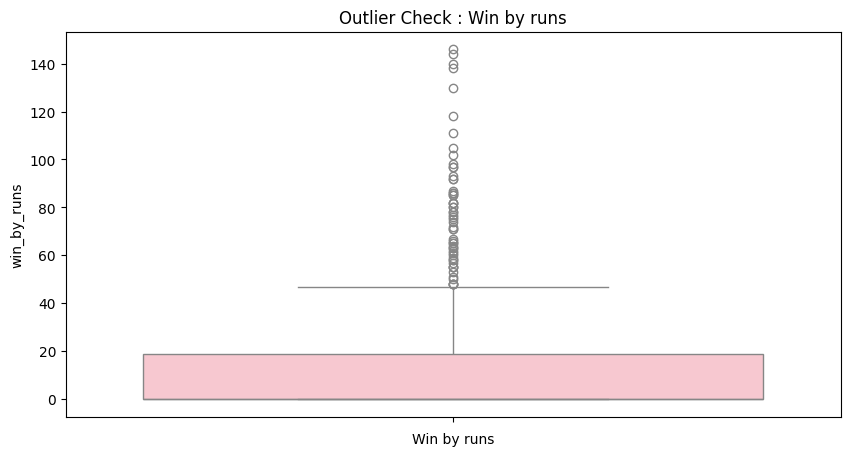

In [93]:
plt.figure(figsize=(10,5))
sns.boxplot(df['win_by_runs'],color='pink')
plt.title("Outlier Check : Win by runs")
plt.xlabel("Win by runs")
plt.show()

In [94]:
#capping the outliers
floor=df['win_by_runs'].quantile(0.05)
df['win_by_runs']=df['win_by_runs'].clip(lower=floor)

In [95]:
#log transformation method to reduce impact of outliers
df['win_by_runs']=np.log(df['win_by_runs'])


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


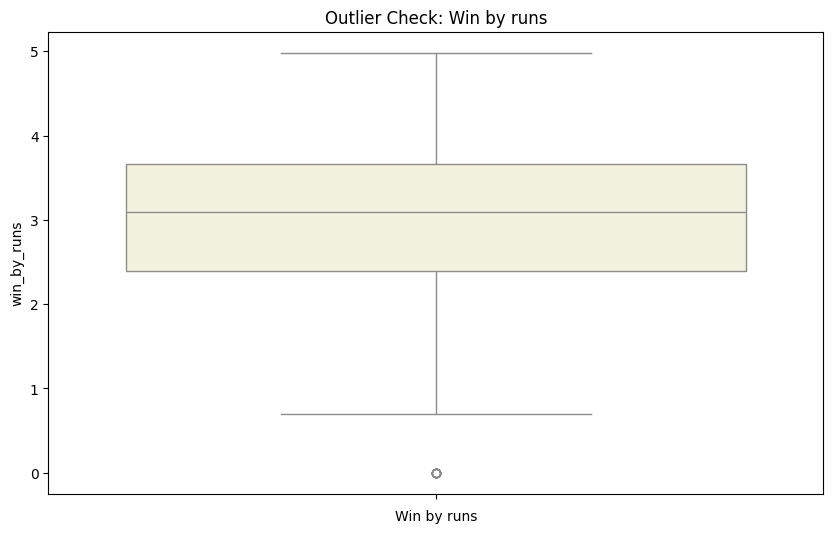

In [96]:
#outliers
plt.figure(figsize=(10,6))
sns.boxplot(df['win_by_runs'],color='beige')
plt.title("Outlier Check: Win by runs")
plt.xlabel('Win by runs')
plt.show()


In [97]:
#gives the number of columns and rows
df.shape

(756, 18)

In [98]:
df.dtypes

,0
id,int64
season,int64
city,object
date,object
team1,object
team2,object
toss_winner,object
toss_decision,object
result,object
dl_applied,int64


In [99]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
from numpy import astype

In [101]:
#convert all the 'obj' variables into 'numerical' values
#1.Identify all 'object' columns
object_cols=df.select_dtypes(include=['object']).columns

'''2.initialize the LabelEncoder(converts categoral text into numerical labels):using when ordered data types is there
#(one hot encoding:converts categoral data into binary format):using when unordered data types is present'''
le=LabelEncoder()

#3.Loop through columns and convert to int
for col in object_cols:
  df[col]=le.fit_transform(df[col].astype(str))
  #fit_transform:it is a function
     #it takes what are parameters we are taking as input(data) and (the unique values identified by fit function)
     # and  help us to  understand the data,then it passes it to LabelEncoder for further actions
     #and also it is useful for model to learn the data
#Handle any float values
# Replace -inf values in 'win_by_runs' with 0, as log(0) results in -inf which cannot be cast to int.
df['win_by_runs'] = df['win_by_runs'].replace(-np.inf, 0)
df=df.astype(int)

# check the results
print(df.dtypes)

id                 int64
season             int64
city               int64
date               int64
team1              int64
team2              int64
toss_winner        int64
toss_decision      int64
result             int64
dl_applied         int64
winner             int64
win_by_runs        int64
win_by_wickets     int64
player_of_match    int64
venue              int64
umpire1            int64
umpire2            int64
umpire3            int64
dtype: object


In [102]:
df.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,14,470,14,13,13,1,1,0,14,3,0,224,28,6,34,5
1,2,2017,26,471,8,11,11,1,1,0,11,0,7,199,21,1,49,5
2,3,2017,28,472,4,7,7,1,1,0,7,0,10,34,31,38,16,5
3,4,2017,15,473,11,5,5,1,1,0,5,0,6,61,13,3,14,5
4,5,2017,2,473,13,3,13,0,1,0,13,2,0,99,17,22,14,5


In [103]:
df.corr()#used to calculate corrolation matrix for a dataframe

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
id,1.000000,0.668304,0.049506,-0.161600,0.087311,-0.005248,-0.023331,0.195225,0.008519,-0.011658,-0.002398,-0.042975,-0.012239,-0.018019,-0.002442,0.153750,-0.029795,0.650604
season,0.668304,1.000000,0.127026,0.451594,0.230947,0.094766,0.138448,0.280989,0.005336,-0.001116,0.143940,-0.050260,-0.009379,-0.086956,0.001909,0.077548,-0.099272,0.430719
city,0.049506,0.127026,1.000000,0.053259,0.018083,-0.026612,0.035702,-0.038266,0.000459,-0.011002,-0.007491,-0.032454,0.029318,0.017952,0.100146,-0.066715,-0.011641,0.048635
date,-0.161600,0.451594,0.053259,1.000000,0.200876,0.085709,0.159056,0.129283,-0.020352,0.003156,0.143644,0.012437,-0.032165,-0.087424,-0.005113,-0.045206,-0.084338,-0.157324
team1,0.087311,0.230947,0.018083,0.200876,1.000000,-0.105600,0.347593,0.122089,0.007869,0.005246,0.394833,-0.034295,0.014638,-0.063502,0.104323,0.011511,-0.048432,0.094068
team2,-0.005248,0.094766,-0.026612,0.085709,-0.105600,1.000000,0.545901,0.010807,-0.016249,0.016700,0.514852,0.010498,0.010624,-0.059797,0.075024,-0.036041,0.005671,-0.005941
toss_winner,-0.023331,0.138448,0.035702,0.159056,0.347593,0.545901,1.000000,0.088610,-0.017580,0.024496,0.486196,-0.034809,0.050468,-0.036081,0.097209,-0.029256,-0.016259,-0.029776
toss_decision,0.195225,0.280989,-0.038266,0.129283,0.122089,0.010807,0.088610,1.000000,-0.022020,0.023655,0.072778,-0.012195,0.005377,-0.014548,-0.049083,0.054315,-0.025065,0.122140
result,0.008519,0.005336,0.000459,-0.020352,0.007869,-0.016249,-0.017580,-0.022020,1.000000,-0.008108,0.019294,-0.039403,-0.049975,0.070167,0.059622,-0.043026,-0.018571,0.036820
dl_applied,-0.011658,-0.001116,-0.011002,0.003156,0.005246,0.016700,0.024496,0.023655,-0.008108,1.000000,0.037580,0.006848,-0.011631,-0.023172,-0.068555,-0.031148,-0.001674,0.005651


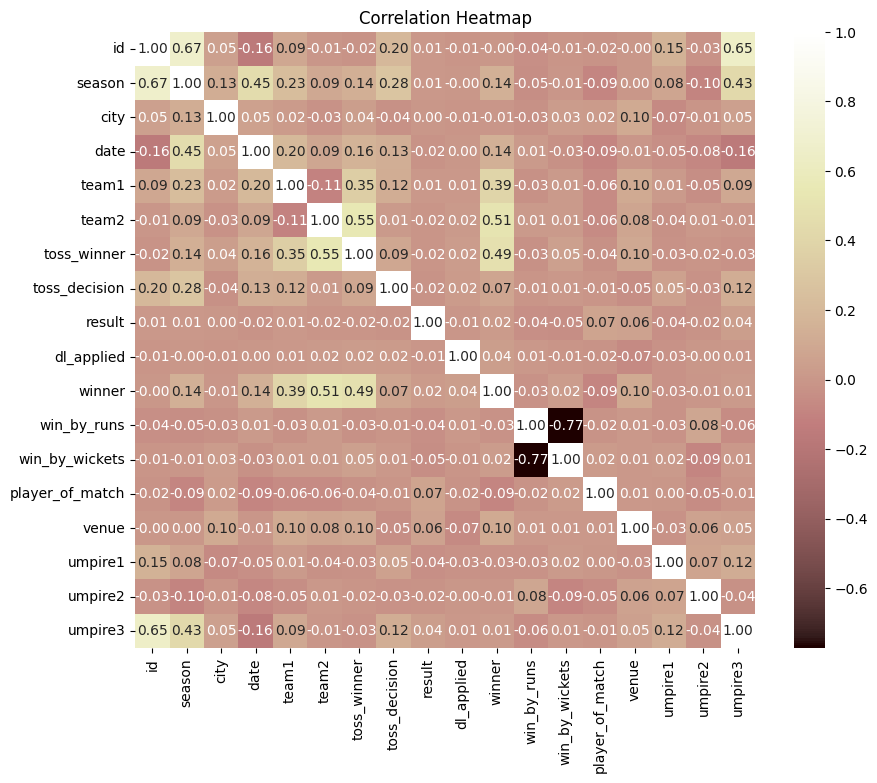

In [104]:
corr = df.corr()

# Plot the Heatmap

plt.figure(figsize=(10, 8))

sns.heatmap(corr, annot=True, cmap='pink', fmt='.2f')#if we want to get numerical value in the map then we have to use annot=true

plt.title('Correlation Heatmap')

plt.show()

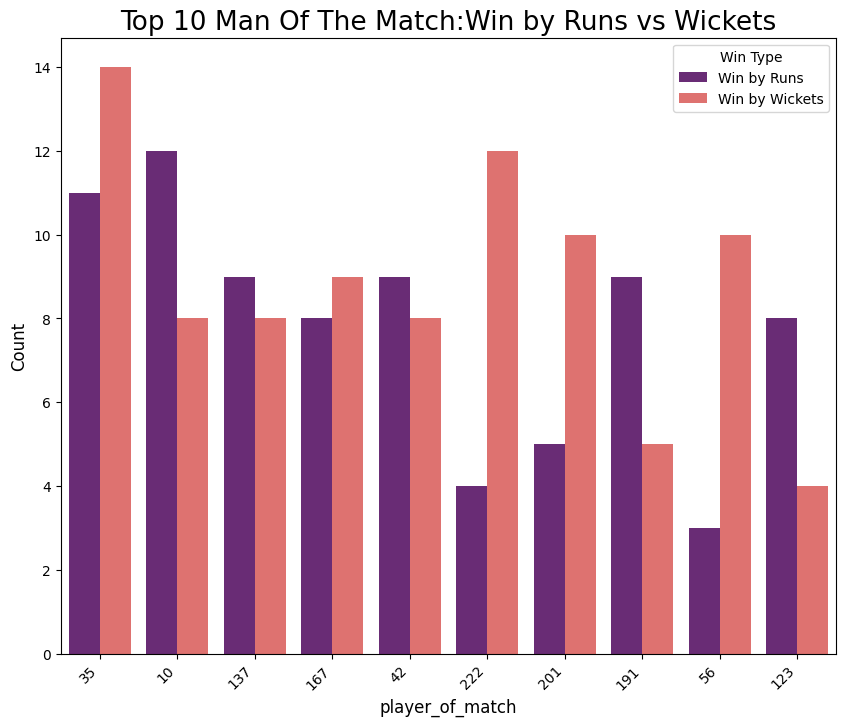

In [109]:
#Bi variable,univariable,Multivariable analysis
#prepare the data
PlayerOFMatch=df['player_of_match'].value_counts().index[:10]
PlayerOFMatch_data=df[df['player_of_match'].isin(PlayerOFMatch)].copy() # Use .copy() to avoid SettingWithCopyWarning

# Create a 'win_type' column based on 'win_by_runs' and 'win_by_wickets'
# Assuming win_by_runs > 0 means win by runs, and win_by_wickets > 0 means win by wickets.
PlayerOFMatch_data['win_type'] = np.where(PlayerOFMatch_data['win_by_runs'] > 0, 'Win by Runs', 'Win by Wickets')


#create the plot
plt.figure(figsize=(10,8))
sns.countplot(data=PlayerOFMatch_data,x='player_of_match',hue='win_type',palette='magma',order=PlayerOFMatch)

#Aesthetics
plt.title('Top 10 Man Of The Match:Win by Runs vs Wickets',fontsize=19)
plt.xlabel('player_of_match',fontsize=12)
plt.ylabel('Count',fontsize=12)
plt.legend(title='Win Type') # Update legend title
plt.xticks(rotation=45,ha='right')
plt.show()